In [ ]:
import sys
from pathlib import Path

# Add project root so we can import from the cityscape_seg package
sys.path.insert(0, str(Path.cwd().parent))

In [ ]:
import glob
import os
import random

import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as T
import torchvision.transforms.functional as TF
from PIL import Image
from skimage.segmentation import find_boundaries
from torch.utils.data import DataLoader, Dataset, Subset

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [63]:
# ── Configuration ──
DATA_ROOT = "./data/small_data"
IMG_HEIGHT, IMG_WIDTH = 256, 512
BATCH_SIZE = 4
NUM_CLASSES = 8
NUM_EPOCHS = 30
LR = 1e-4
NUM_TRAIN = 400  # use a small subset for fast iteration
NUM_VAL = 100

CLASS_NAMES = [
    "road/drivable",  # 0
    "sidewalk",  # 1
    "human",  # 2
    "vehicle",  # 3
    "traffic object",  # 4
    "nature",  # 5  (vegetation, terrain, sky)
    "construction",  # 6  (building, wall, fence, guard rail, bridge, tunnel)
    "background",  # 7  (void classes)
]

CLASS_COLORS = [
    (128, 64, 128),  # road – purple
    (244, 35, 232),  # sidewalk – pink
    (220, 20, 60),  # human – crimson
    (0, 0, 142),  # vehicle – dark blue
    (250, 170, 30),  # traffic object – orange
    (107, 142, 35),  # nature – olive green
    (70, 70, 70),  # construction – dark gray
    (0, 0, 0),  # background – black
]

In [49]:
# ── Cityscapes label-ID → 6-class remapping ──
# Cityscapes labelIds: https://github.com/mcordts/cityscapesScripts
# 0-6: void/ego/rectification/out-of-roi/static/dynamic/ground
# 7 road, 8 sidewalk, 9 parking, 10 rail track
# 11 building, 12 wall, 13 fence, 14 guard rail, 15 bridge, 16 tunnel
# 17 pole, 18 polegroup, 19 traffic light, 20 traffic sign
# 21 vegetation, 22 terrain, 23 sky
# 24 person, 25 rider
# 26 car, 27 truck, 28 bus, 29 caravan, 30 trailer, 31 train, 32 motorcycle, 33 bicycle
# 255 / -1: license plate (ignored)

LABEL_REMAP = np.full(256, 7, dtype=np.uint8)  # default → background (void)

# Class 0: road / drivable area
for lid in [7, 9, 10]:
    LABEL_REMAP[lid] = 0

# Class 1: sidewalk
LABEL_REMAP[8] = 1

# Class 2: human
for lid in [24, 25]:
    LABEL_REMAP[lid] = 2

# Class 3: vehicle
for lid in [26, 27, 28, 29, 30, 31, 32, 33]:
    LABEL_REMAP[lid] = 3

# Class 4: traffic object
for lid in [17, 18, 19, 20]:
    LABEL_REMAP[lid] = 4

# Class 5: nature (vegetation, terrain, sky)
for lid in [21, 22, 23]:
    LABEL_REMAP[lid] = 5

# Class 6: construction (building, wall, fence, guard rail, bridge, tunnel)
for lid in [11, 12, 13, 14, 15, 16]:
    LABEL_REMAP[lid] = 6

# Class 7: background (everything else — void classes default to 7)

print("Remap table (non-background entries):")
for i in range(34):
    if LABEL_REMAP[i] != 7:
        print(f"  labelId {i:>2d} → class {LABEL_REMAP[i]} ({CLASS_NAMES[LABEL_REMAP[i]]})")

Remap table (non-background entries):
  labelId  7 → class 0 (road/drivable)
  labelId  8 → class 1 (sidewalk)
  labelId  9 → class 0 (road/drivable)
  labelId 10 → class 0 (road/drivable)
  labelId 11 → class 6 (construction)
  labelId 12 → class 6 (construction)
  labelId 13 → class 6 (construction)
  labelId 14 → class 6 (construction)
  labelId 15 → class 6 (construction)
  labelId 16 → class 6 (construction)
  labelId 17 → class 4 (traffic object)
  labelId 18 → class 4 (traffic object)
  labelId 19 → class 4 (traffic object)
  labelId 20 → class 4 (traffic object)
  labelId 21 → class 5 (nature)
  labelId 22 → class 5 (nature)
  labelId 23 → class 5 (nature)
  labelId 24 → class 2 (human)
  labelId 25 → class 2 (human)
  labelId 26 → class 3 (vehicle)
  labelId 27 → class 3 (vehicle)
  labelId 28 → class 3 (vehicle)
  labelId 29 → class 3 (vehicle)
  labelId 30 → class 3 (vehicle)
  labelId 31 → class 3 (vehicle)
  labelId 32 → class 3 (vehicle)
  labelId 33 → class 3 (vehicle)


In [50]:
# ── Paired image-label augmentation transforms ──
# Spatial transforms are applied identically to both image and label.
# Photometric transforms (ColorJitter) are applied to the image only.
# Source: adapted from https://github.com/pytorch/vision/blob/master/references/segmentation/transforms.py


class PairedCompose:
    def __init__(self, transforms):
        self.transforms = transforms

    def __call__(self, image, target):
        for t in self.transforms:
            image, target = t(image, target)
        return image, target


class PairedRandomHorizontalFlip:
    def __init__(self, p=0.5):
        self.p = p

    def __call__(self, image, target):
        if random.random() < self.p:
            image = TF.hflip(image)
            target = TF.hflip(target)
        return image, target


class PairedColorJitter:
    """Applies color jitter to the image only (labels are unchanged)."""

    def __init__(self, brightness=0, contrast=0, saturation=0, hue=0):
        self.jitter = T.ColorJitter(brightness, contrast, saturation, hue)

    def __call__(self, image, target):
        return self.jitter(image), target


class PairedRandomResizedCrop:
    """Random crop + resize back to target size (same crop for both)."""

    def __init__(self, size, scale=(0.5, 1.0), ratio=(0.75, 1.33)):
        self.size = size
        self.scale = scale
        self.ratio = ratio

    def __call__(self, image, target):
        i, j, h, w = T.RandomResizedCrop.get_params(image, self.scale, self.ratio)
        image = TF.resized_crop(
            image, i, j, h, w, self.size, interpolation=TF.InterpolationMode.BILINEAR
        )
        target = TF.resized_crop(
            target, i, j, h, w, self.size, interpolation=TF.InterpolationMode.NEAREST
        )
        return image, target


class PairedToTensorAndNormalize:
    """Convert PIL image to tensor + ImageNet-normalize; convert label to numpy."""

    def __init__(self, mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)):
        self.normalize = T.Normalize(mean=mean, std=std)

    def __call__(self, image, target):
        image = self.normalize(TF.to_tensor(image))
        target = np.array(target, dtype=np.uint8)
        return image, target


# ── Build train / val transform pipelines ──
train_transform = PairedCompose(
    [
        PairedRandomHorizontalFlip(p=0.5),
        PairedColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
        PairedRandomResizedCrop(size=(IMG_HEIGHT, IMG_WIDTH), scale=(0.5, 1.0)),
        PairedToTensorAndNormalize(),
    ]
)

val_transform = PairedCompose(
    [
        PairedToTensorAndNormalize(),
    ]
)

In [51]:
# ── Dataset (preloaded PIL images, augmentation applied per-access) ──
class CityscapesSegDataset(Dataset):
    """Loads all Cityscapes images + labels into memory as resized PIL images.

    Augmentation transforms are applied lazily in __getitem__ so that each
    epoch sees different random variations of the training data.
    """

    def __init__(self, root_dir, split="train", img_size=(IMG_HEIGHT, IMG_WIDTH), transform=None):
        split_dir = os.path.join(root_dir, split)
        self.transform = transform
        self.img_size = img_size

        image_paths = sorted(glob.glob(os.path.join(split_dir, "*_leftImg8bit.png")))
        label_paths = sorted(glob.glob(os.path.join(split_dir, "*_labelIds.png")))
        assert len(image_paths) == len(label_paths), (
            f"Mismatch: {len(image_paths)} images vs {len(label_paths)} labels"
        )
        n = len(image_paths)
        print(f"[{split}] Loading {n} image-label pairs into memory …")

        self.images, self.labels = [], []
        for i, (ip, lp) in enumerate(zip(image_paths, label_paths)):
            img = Image.open(ip).convert("RGB")
            lbl = Image.open(lp)

            img = TF.resize(img, img_size, interpolation=TF.InterpolationMode.BILINEAR)
            lbl = TF.resize(lbl, img_size, interpolation=TF.InterpolationMode.NEAREST)

            self.images.append(img)
            self.labels.append(lbl)

            if (i + 1) % 500 == 0 or (i + 1) == n:
                print(f"  {i + 1}/{n}")

        print(f"[{split}] Done — {n} PIL image-label pairs loaded.")

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img, lbl = self.images[idx], self.labels[idx]

        if self.transform is not None:
            img, lbl = self.transform(img, lbl)

        # img is now a normalized [3, H, W] tensor; lbl is a uint8 numpy array
        lbl_np = (
            LABEL_REMAP[lbl]
            if isinstance(lbl, np.ndarray)
            else LABEL_REMAP[np.array(lbl, dtype=np.uint8)]
        )
        lbl_t = torch.from_numpy(lbl_np).long()

        boundary = find_boundaries(lbl_np, mode="outer").astype(np.uint8)
        boundary += 1  # 1 = interior, 2 = boundary
        mask = torch.from_numpy(boundary).float()

        return img, lbl_t, mask

In [52]:
# ── DataLoaders (small subset) ──
train_full = CityscapesSegDataset(DATA_ROOT, "train", transform=train_transform)
val_full = CityscapesSegDataset(DATA_ROOT, "valid", transform=val_transform)

[train] Loading 2975 image-label pairs into memory …
  500/2975
  1000/2975
  1500/2975
  2000/2975
  2500/2975
  2975/2975
[train] Done — 2975 PIL image-label pairs loaded.
[valid] Loading 500 image-label pairs into memory …
  500/500
[valid] Done — 500 PIL image-label pairs loaded.


In [64]:
rng = np.random.default_rng(42)
train_idx = rng.choice(len(train_full), size=min(NUM_TRAIN, len(train_full)), replace=False)
val_idx = rng.choice(len(val_full), size=min(NUM_VAL, len(val_full)), replace=False)

train_ds = Subset(train_full, train_idx)
val_ds = Subset(val_full, val_idx)

train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True
)
val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True
)

print(f"Train subset: {len(train_ds)} samples  ({len(train_loader)} batches)")
print(f"Val   subset: {len(val_ds)} samples  ({len(val_loader)} batches)")

Train subset: 400 samples  (100 batches)
Val   subset: 100 samples  (25 batches)


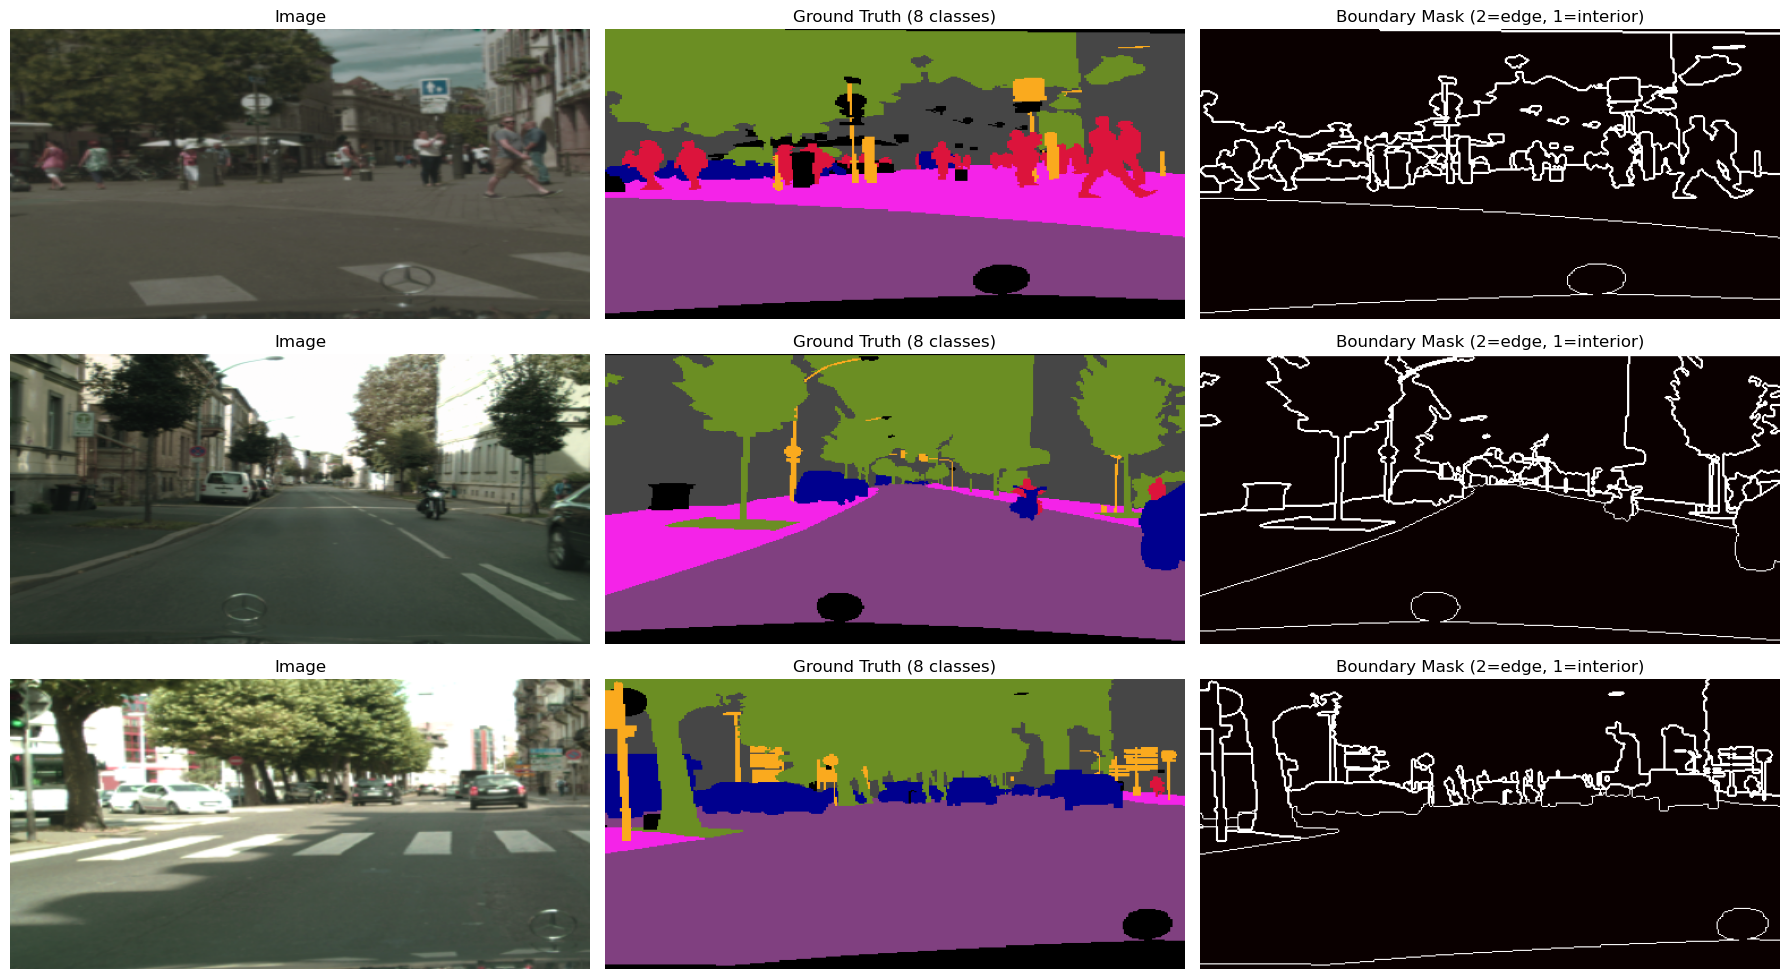

In [65]:
# ── Visualize a few training samples ──
def label_to_color(lbl_np):
    """Convert a HxW label map to an HxWx3 RGB image."""
    h, w = lbl_np.shape
    rgb = np.zeros((h, w, 3), dtype=np.uint8)
    for cls_id, color in enumerate(CLASS_COLORS):
        rgb[lbl_np == cls_id] = color
    return rgb


inv_normalize = T.Normalize(
    mean=[-0.485 / 0.229, -0.456 / 0.224, -0.406 / 0.225],
    std=[1 / 0.229, 1 / 0.224, 1 / 0.225],
)

fig, axes = plt.subplots(3, 3, figsize=(18, 10))
for i in range(3):
    img, lbl, mask = train_ds[i]
    img_vis = inv_normalize(img).permute(1, 2, 0).clamp(0, 1).numpy()
    lbl_vis = label_to_color(lbl.numpy())
    mask_vis = mask.numpy()

    axes[i, 0].imshow(img_vis)
    axes[i, 0].set_title("Image")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(lbl_vis)
    axes[i, 1].set_title(f"Ground Truth ({NUM_CLASSES} classes)")
    axes[i, 1].axis("off")

    axes[i, 2].imshow(mask_vis, cmap="hot", vmin=1, vmax=2)
    axes[i, 2].set_title("Boundary Mask (2=edge, 1=interior)")
    axes[i, 2].axis("off")

plt.tight_layout()
plt.show()

Class pixel distribution:
  road/drivable         pixels:   19717700  (37.6%)  weight: 0.108
  sidewalk              pixels:    1955362  (3.7%)  weight: 1.094
  human                 pixels:     729276  (1.4%)  weight: 2.933
  vehicle               pixels:    3073160  (5.9%)  weight: 0.696
  traffic object        pixels:     911828  (1.7%)  weight: 2.346
  nature                pixels:   10609229  (20.2%)  weight: 0.202
  construction          pixels:   10248196  (19.5%)  weight: 0.209
  background            pixels:    5184051  (9.9%)  weight: 0.413


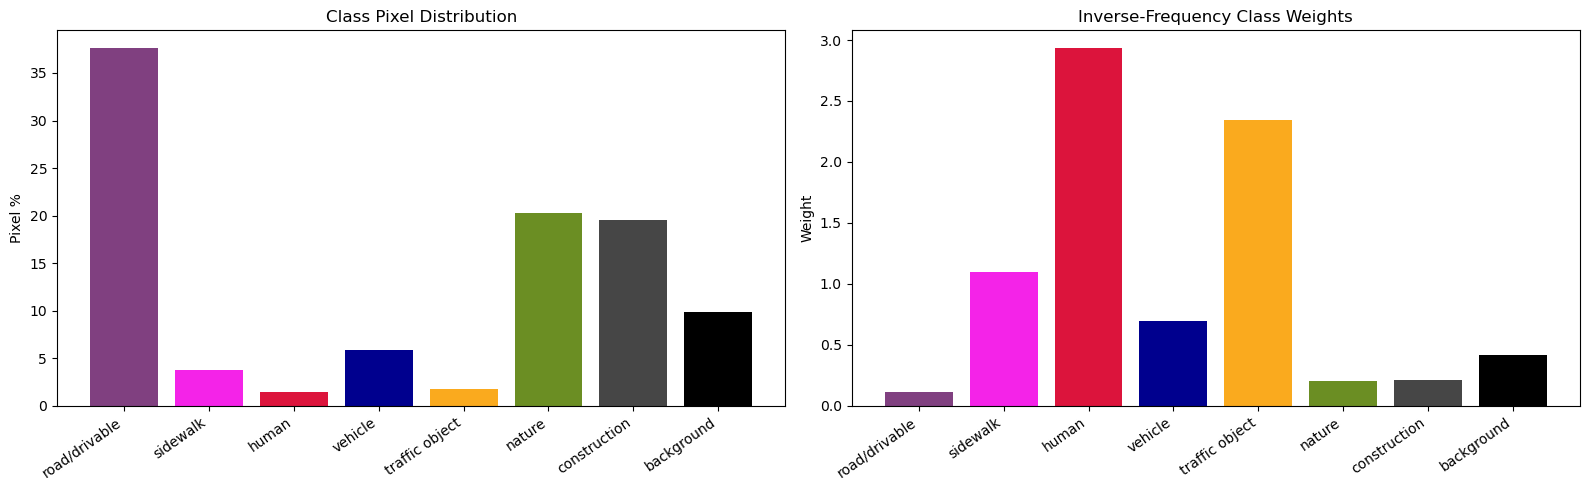

In [69]:
# ── Class weights + Focal Loss ──

# Compute inverse-frequency weights from the training subset
pixel_counts = torch.zeros(NUM_CLASSES)
for _, lbl, _ in train_loader:
    for c in range(NUM_CLASSES):
        pixel_counts[c] += (lbl == c).sum()

freq = pixel_counts / pixel_counts.sum()
inv_freq = 1.0 / (freq + 1e-6)
class_weights = (inv_freq / inv_freq.sum() * NUM_CLASSES).to(device)

print("Class pixel distribution:")
for name, cnt, w in zip(CLASS_NAMES, pixel_counts, class_weights):
    print(
        f"  {name:<20s}  pixels: {cnt.item():>10.0f}  ({freq[CLASS_NAMES.index(name)] * 100:.1f}%)  weight: {w:.3f}"
    )

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

colors = [np.array(c) / 255 for c in CLASS_COLORS]
x = range(NUM_CLASSES)

ax1.bar(x, freq.numpy() * 100, color=colors)
ax1.set_xticks(x)
ax1.set_xticklabels(CLASS_NAMES, rotation=35, ha="right")
ax1.set_ylabel("Pixel %")
ax1.set_title("Class Pixel Distribution")

ax2.bar(x, class_weights.cpu().numpy(), color=colors)
ax2.set_xticks(x)
ax2.set_xticklabels(CLASS_NAMES, rotation=35, ha="right")
ax2.set_ylabel("Weight")
ax2.set_title("Inverse-Frequency Class Weights")

plt.tight_layout()
plt.show()


class FocalLoss(nn.Module):
    """Weighted Focal Loss for multi-class segmentation.

    FL(p_t) = -alpha_t * (1 - p_t)^gamma * log(p_t)

    Args:
        alpha:  per-class weights, shape [C]. Balances rare vs frequent classes.
        gamma:  focusing parameter (>=0). Higher values down-weight easy examples more.
                gamma=0 reduces to weighted cross-entropy.
    """

    def __init__(self, alpha=None, gamma=2.0):
        super().__init__()
        self.gamma = gamma
        if alpha is not None:
            self.register_buffer("alpha", alpha.clone())
        else:
            self.alpha = None

    def forward(self, logits, targets, mask=None):
        # logits: [B, C, H, W],  targets: [B, H, W],  mask: [B, H, W] (optional)
        ce = nn.functional.cross_entropy(logits, targets, reduction="none")  # [B, H, W]
        pt = torch.exp(-ce)  # predicted probability of the true class

        focal = (1.0 - pt) ** self.gamma * ce  # [B, H, W]

        if self.alpha is not None:
            alpha_t = self.alpha[targets]  # per-pixel weight based on true class
            focal = alpha_t * focal

        if mask is not None:
            focal = focal * mask  # boundary pixels get higher weight

        return focal.mean()


# criterion = FocalLoss(alpha=class_weights, gamma=2.0)
# print(f"\nFocal Loss  |  gamma={criterion.gamma}  |  alpha={class_weights.cpu().tolist()}")
criterion = nn.CrossEntropyLoss(weight=class_weights).to(device)

In [70]:
# ── FCN-8s Model (built from scratch) ──
#
# Architecture following Long et al. "Fully Convolutional Networks
# for Semantic Segmentation" (CVPR 2015):
#
#   Encoder : 5 VGG-style blocks (conv-bn-relu pairs + maxpool)
#   Bridge  : two 1x1 conv layers (replace the original FC6/FC7)
#   Decoder : transposed convolutions with FCN-8s skip connections
#             from pool3 and pool4 for fine-grained spatial detail
#
# Input  : (B, 3, 256, 512)
# Output : (B, NUM_CLASSES, 256, 512)  – logits, same size as input


class ConvBlock(nn.Module):
    """N consecutive (Conv3x3 → BN → ReLU) layers."""

    def __init__(self, in_ch, out_ch, n_convs=2):
        super().__init__()
        layers = []
        for i in range(n_convs):
            layers.append(nn.Conv2d(in_ch if i == 0 else out_ch, out_ch, 3, padding=1))
            layers.append(nn.BatchNorm2d(out_ch))
            layers.append(nn.ReLU(inplace=True))
        self.block = nn.Sequential(*layers)

    def forward(self, x):
        return self.block(x)


class FCN8s(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        # ── Encoder ──
        self.enc1 = ConvBlock(3, 64, n_convs=2)  # /1
        self.enc2 = ConvBlock(64, 128, n_convs=2)  # /2
        self.enc3 = ConvBlock(128, 256, n_convs=3)  # /4
        self.enc4 = ConvBlock(256, 512, n_convs=3)  # /8
        self.enc5 = ConvBlock(512, 512, n_convs=3)  # /16

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # ── Bridge (replaces FC6 / FC7) ──
        self.bridge = nn.Sequential(
            nn.Conv2d(512, 1024, 1),
            nn.BatchNorm2d(1024),
            nn.ReLU(inplace=True),
            nn.Dropout2d(0.5),
            nn.Conv2d(1024, 1024, 1),
            nn.BatchNorm2d(1024),
            nn.ReLU(inplace=True),
            nn.Dropout2d(0.5),
        )

        # ── Decoder (FCN-8s) ──
        # score from bridge  → num_classes channels at /32
        self.score_bridge = nn.Conv2d(1024, num_classes, 1)

        # upsample /32 → /16,  fuse with pool4 skip
        self.up_bridge = nn.ConvTranspose2d(num_classes, num_classes, 4, stride=2, padding=1)
        self.score_pool4 = nn.Conv2d(512, num_classes, 1)

        # upsample /16 → /8,  fuse with pool3 skip
        self.up_pool4 = nn.ConvTranspose2d(num_classes, num_classes, 4, stride=2, padding=1)
        self.score_pool3 = nn.Conv2d(256, num_classes, 1)

        # upsample /8 → /1  (8× bilinear-initialised)
        self.up_final = nn.ConvTranspose2d(num_classes, num_classes, 16, stride=8, padding=4)

        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, nonlinearity="relu")
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.ConvTranspose2d):
                # bilinear upsampling initialisation
                nn.init.kaiming_normal_(m.weight, nonlinearity="relu")
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        # ── Encoder ──
        e1 = self.enc1(x)  # (B,  64, H,   W)
        p1 = self.pool(e1)  # (B,  64, H/2, W/2)

        e2 = self.enc2(p1)  # (B, 128, H/2, W/2)
        p2 = self.pool(e2)  # (B, 128, H/4, W/4)

        e3 = self.enc3(p2)  # (B, 256, H/4, W/4)
        p3 = self.pool(e3)  # (B, 256, H/8, W/8)     ← pool3 skip

        e4 = self.enc4(p3)  # (B, 512, H/8, W/8)
        p4 = self.pool(e4)  # (B, 512, H/16, W/16)   ← pool4 skip

        e5 = self.enc5(p4)  # (B, 512, H/16, W/16)
        p5 = self.pool(e5)  # (B, 512, H/32, W/32)

        # ── Bridge ──
        b = self.bridge(p5)  # (B, 1024, H/32, W/32)

        # ── Decoder with skip connections ──
        s_bridge = self.score_bridge(b)  # (B, C, H/32, W/32)
        up1 = self.up_bridge(s_bridge)  # (B, C, H/16, W/16)
        s_pool4 = self.score_pool4(p4)  # (B, C, H/16, W/16)
        fuse1 = up1 + s_pool4

        up2 = self.up_pool4(fuse1)  # (B, C, H/8, W/8)
        s_pool3 = self.score_pool3(p3)  # (B, C, H/8, W/8)
        fuse2 = up2 + s_pool3

        out = self.up_final(fuse2)  # (B, C, H, W)
        return out


model = FCN8s(NUM_CLASSES).to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Custom FCN-8s  |  Total params: {total_params:,}  |  Trainable: {trainable_params:,}")

# Verify output shape
with torch.no_grad():
    dummy = torch.randn(1, 3, IMG_HEIGHT, IMG_WIDTH, device=device)
    out = model(dummy)
    print(f"Input: {dummy.shape} → Output: {out.shape}")

Custom FCN-8s  |  Total params: 16,334,960  |  Trainable: 16,334,960
Input: torch.Size([1, 3, 256, 512]) → Output: torch.Size([1, 8, 256, 512])


In [71]:
# ── Training loop ──
# criterion is defined above (Focal Loss with class weights)
optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=1e-3)

train_losses, val_losses = [], []
train_accs, val_accs = [], []

for epoch in range(1, NUM_EPOCHS + 1):
    # ─── Train ───
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for imgs, lbls, masks in train_loader:
        imgs, lbls, masks = imgs.to(device), lbls.to(device), masks.to(device)

        optimizer.zero_grad()
        out = model(imgs)  # [B, C, H, W]
        # loss = criterion(out, lbls, masks) # focal loss
        loss = criterion(out, lbls)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * imgs.size(0)
        preds = out.argmax(dim=1)
        correct += (preds == lbls).sum().item()
        total += lbls.numel()

    train_losses.append(running_loss / len(train_ds))
    train_accs.append(correct / total)

    # ─── Validate ───
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for imgs, lbls, masks in val_loader:
            imgs, lbls, masks = imgs.to(device), lbls.to(device), masks.to(device)
            out = model(imgs)
            # loss = criterion(out, lbls, masks)
            loss = criterion(out, lbls)

            running_loss += loss.item() * imgs.size(0)
            preds = out.argmax(dim=1)
            correct += (preds == lbls).sum().item()
            total += lbls.numel()

    val_losses.append(running_loss / len(val_ds))
    val_accs.append(correct / total)

    if epoch % 5 == 0 or epoch == 1:
        print(
            f"Epoch {epoch:>3d}/{NUM_EPOCHS}  "
            f"Train Loss: {train_losses[-1]:.4f}  Acc: {train_accs[-1]:.4f}  |  "
            f"Val Loss: {val_losses[-1]:.4f}  Acc: {val_accs[-1]:.4f}"
        )

print("\nTraining complete.")

Epoch   1/30  Train Loss: 1.9651  Acc: 0.2521  |  Val Loss: 1.7546  Acc: 0.3885
Epoch   5/30  Train Loss: 1.0819  Acc: 0.6575  |  Val Loss: 1.0937  Acc: 0.6759
Epoch  10/30  Train Loss: 0.8865  Acc: 0.7112  |  Val Loss: 1.0891  Acc: 0.6492
Epoch  15/30  Train Loss: 0.7841  Acc: 0.7444  |  Val Loss: 0.9423  Acc: 0.7212
Epoch  20/30  Train Loss: 0.7052  Acc: 0.7645  |  Val Loss: 0.8043  Acc: 0.7419
Epoch  25/30  Train Loss: 0.6625  Acc: 0.7850  |  Val Loss: 0.9116  Acc: 0.7561
Epoch  30/30  Train Loss: 0.6266  Acc: 0.7913  |  Val Loss: 0.7504  Acc: 0.7514

Training complete.


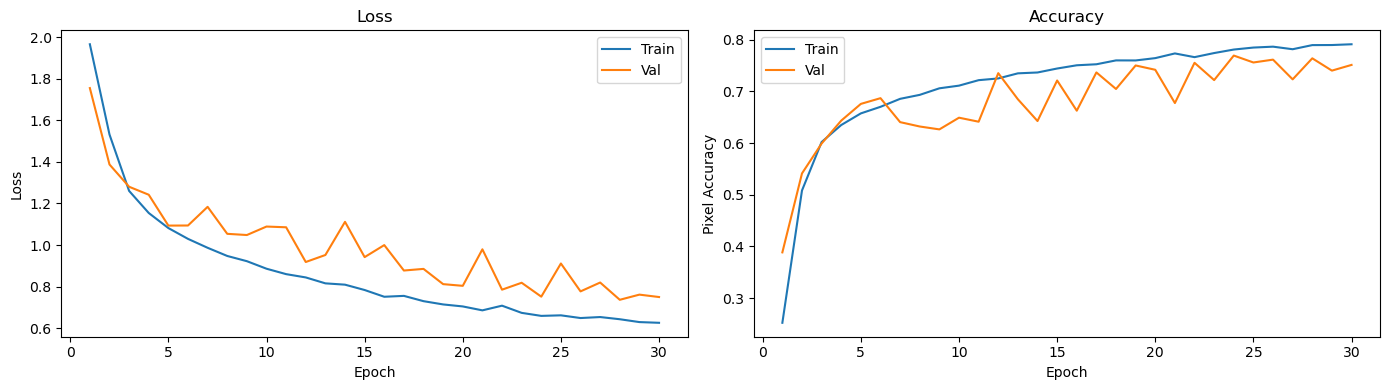

In [72]:
# ── Training curves ──
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
epochs_range = range(1, NUM_EPOCHS + 1)

ax1.plot(epochs_range, train_losses, label="Train")
ax1.plot(epochs_range, val_losses, label="Val")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.set_title("Loss")
ax1.legend()

ax2.plot(epochs_range, train_accs, label="Train")
ax2.plot(epochs_range, val_accs, label="Val")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Pixel Accuracy")
ax2.set_title("Accuracy")
ax2.legend()

plt.tight_layout()
plt.show()

In [73]:
# ── Evaluation: per-class IoU and mIoU ──
def compute_miou(model, loader, num_classes, device):
    """Compute per-class IoU and mean IoU over a DataLoader."""
    confusion = torch.zeros(num_classes, num_classes, dtype=torch.long)
    model.eval()
    with torch.no_grad():
        for imgs, lbls, _ in loader:
            imgs = imgs.to(device)
            preds = model(imgs).argmax(dim=1).cpu()
            # vectorized confusion matrix accumulation
            t_flat = lbls.view(-1)
            p_flat = preds.view(-1)
            indices = t_flat * num_classes + p_flat
            confusion += torch.bincount(indices, minlength=num_classes**2).reshape(
                num_classes, num_classes
            )

    ious = []
    for c in range(num_classes):
        tp = confusion[c, c].item()
        fp = confusion[:, c].sum().item() - tp
        fn = confusion[c, :].sum().item() - tp
        denom = tp + fp + fn
        ious.append(tp / denom if denom > 0 else 0.0)
    return ious


ious = compute_miou(model, val_loader, NUM_CLASSES, device)
print(f"{'Class':<20s} {'IoU':>8s}")
print("-" * 30)
for name, iou in zip(CLASS_NAMES, ious):
    print(f"{name:<20s} {iou:>8.4f}")
print("-" * 30)
print(f"{'mIoU':<20s} {np.mean(ious):>8.4f}")

Class                     IoU
------------------------------
road/drivable          0.8293
sidewalk               0.4454
human                  0.1618
vehicle                0.6124
traffic object         0.1501
nature                 0.7165
construction           0.5245
background             0.5688
------------------------------
mIoU                   0.5011


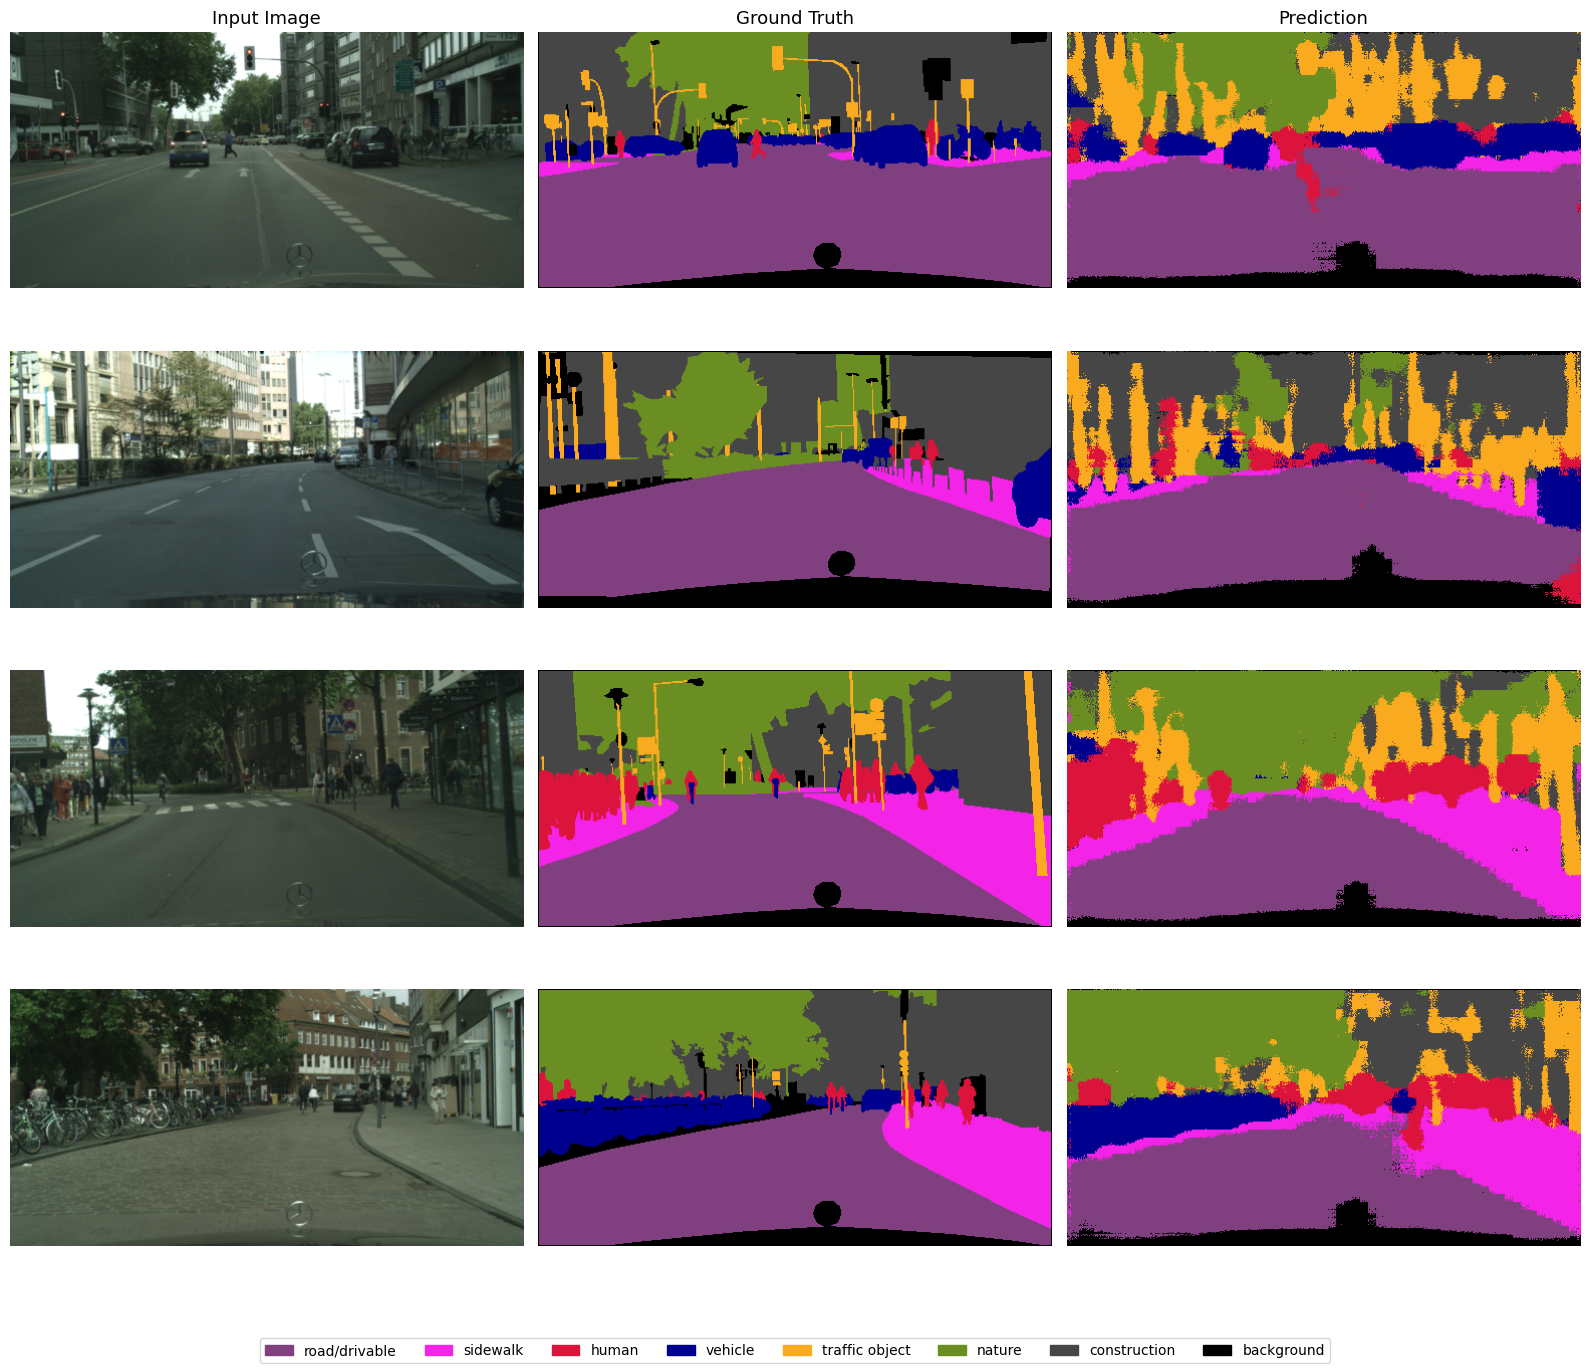

In [ ]:
# ── Visualize predictions on validation set ──
model.eval()
fig, axes = plt.subplots(4, 3, figsize=(16, 14))
col_titles = ["Input Image", "Ground Truth", "Prediction"]

for i in range(4):
    img, lbl, _ = val_ds[i]
    with torch.no_grad():
        pred = model(img.unsqueeze(0).to(device)).argmax(dim=1).squeeze(0).cpu().numpy()

    img_vis = inv_normalize(img).permute(1, 2, 0).clamp(0, 1).numpy()
    gt_vis = label_to_color(lbl.numpy())
    pred_vis = label_to_color(pred)

    axes[i, 0].imshow(img_vis)
    axes[i, 1].imshow(gt_vis)
    axes[i, 2].imshow(pred_vis)

    for j in range(3):
        axes[i, j].axis("off")
        if i == 0:
            axes[i, j].set_title(col_titles[j], fontsize=13)

patches = [
    mpatches.Patch(color=np.array(c) / 255, label=n) for c, n in zip(CLASS_COLORS, CLASS_NAMES)
]
fig.legend(handles=patches, loc="lower center", ncol=NUM_CLASSES, fontsize=10)
plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.show()